In [1]:
!python3 -m pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 2.2 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.6 MB 2.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 2.1/9.6 MB 2.1 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.6 MB 2.2 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.6 MB 2.2 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.6 MB 2.1 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.6 MB 2.1 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.6 MB 2.2 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.6 MB 2.2 MB/s eta 0:00:03
   ---------------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\trakh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import glob
import os

# Folder containing the 20 CSV files
data_path = "true_emp"

# Automatically find all .csv files in folder
csv_files = sorted(glob.glob(os.path.join(data_path, "*.csv")))

# Prepare an empty list to collect sub-dataframes
all_dfs = []

# Loop through all files and read them one by one
for i, file in enumerate(csv_files, start=1):
    # Derive model name from filename (optional)
    # e.g., "LLM_FLARE_trial1.csv" → "LLM_FLARE_trial1"
    # model_name = os.path.splitext(os.path.basename(file))[0]
    
    # Read inventory values (assumed one per line, 50 values total)
    data = pd.read_csv(file, header=None, names=["inventory_size"])
    
    # Assign crafting step numbers (1–50)
    data["step"] = range(1, len(data) + 1)
    
    # Assign model and trial identifiers
    data["model"] = "true_emp"
    data["trial"] = i  # could also use filename patterns instead
    
    # Append to main DataFrame list
    all_dfs.append(data)

# Combine into one master DataFrame
df = pd.concat(all_dfs, ignore_index=True)

# Optional rearrangement of columns to match schema
df = df[["model", "trial", "step", "inventory_size"]]

print(df.head())
print(df.shape)  # should show (20 * 50) rows total = 1000

# Save combined data if needed
df.to_csv(f"combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv", index=False)


      model  trial  step  inventory_size
0  true_emp      1     1  inventory_size
1  true_emp      1     2               5
2  true_emp      1     3               6
3  true_emp      1     4               7
4  true_emp      1     5               8
(1020, 4)


<>:43: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3636378777.py:43: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv(f"combined_inventory_data\combined_inventory_data_{data_path}_50iters_20trials.csv", index=False)


In [ ]:
import os
import json
import pandas as pd

# Define base directory where trial files are located
base_dir = "trail_20_with_fallback\with"  # adjust to where your trial_*.json/.jsonl files are stored

# Prepare an empty list to collect all DataFrames
all_trials = []

# Loop through all trial summary files
for trial_num in range(1, 21):  # as    suming 20 trials total
    summary_path = os.path.join(base_dir, f"trial_{trial_num}_summary.json")
    history_path = os.path.join(base_dir, f"trial_{trial_num}_history.jsonl")

    if not (os.path.exists(summary_path) and os.path.exists(history_path)):
        print(f"Skipping missing files for trial {trial_num}")
        continue

    # --- Read summary file ---
    with open(summary_path, "r") as f:
        summary = json.load(f)

    # You can optionally use this to capture global info
    # model_name = summary.get("model", "LLM_Model")  # default label if not defined
    attempts = summary.get("attempts", None)
    valids = summary.get("valids", None)
    final_inventory = summary.get("final_inventory_size", None)
    fallback_attempts = summary.get("fallback_attempts", None)

    # --- Read jsonl history file ---
    trial_data = []
    with open(history_path, "r") as f:
        for line in f:
            if line.strip():
                record = json.loads(line)
                trial_data.append({
                    "model": "with_fallback",
                    "trial": trial_num,
                    "step": record.get("iter"),
                    "inventory_size": record.get("inventory_size"),
                    "valid": record.get("valid"),
                    "empowerment": record.get("empowerment"),
                    "mode": record.get("mode"),
                    "fallback_reason": record.get("fallback_reason"),
                })

    # Convert this trial into a DataFrame
    trial_df = pd.DataFrame(trial_data)

    # Optionally, only keep the main columns used for analysis
    trial_df = trial_df[["model", "trial", "step", "inventory_size"]]

    # Store this trial’s data
    all_trials.append(trial_df)

# Combine all trials into one master DataFrame
df = pd.concat(all_trials, ignore_index=True)

# Check resulting format
print(df.head())
print(f"Total rows: {df.shape[0]} (Expected ~{50 * len(all_trials)} if 50 steps per trial)")

# Optional: Save to a file for reuse
df.to_csv("combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv", index=False)


           model  trial  step  inventory_size
0  with_fallback      1     1               5
1  with_fallback      1     2               6
2  with_fallback      1     3               7
3  with_fallback      1     4               8
4  with_fallback      1     5               9
Total rows: 1000 (Expected ~1000 if 50 steps per trial)


<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\w'
<>:65: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\2467241068.py:6: SyntaxWarning: invalid escape sequence '\w'
  base_dir = "trail_20_with_fallback\with"  # adjust to where your trial_*.json/.jsonl files are stored
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\2467241068.py:65: SyntaxWarning: invalid escape sequence '\c'
  df.to_csv("combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv", index=False)


In [15]:
file_paths = [
    "combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv",
    "combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv"
]

df_list = []
for file in file_paths:
    temp_df = pd.read_csv(file)
    temp_df["model"] = "true_emp" if "emp" in file.lower() else "with_fallback"
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3880121843.py:2: SyntaxWarning: invalid escape sequence '\c'
  "combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv",
C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\3880121843.py:3: SyntaxWarning: invalid escape sequence '\c'
  "combined_inventory_data\combined_inventory_data_with_fallback_50iters_20trials.csv"


Descriptive Statistics:
                  mean        std  count
model                                  
true_emp       22.200   8.883294   1000
with_fallback  27.464  12.489623   1000 

T-Test: true_emp vs with_fallback -> t=nan, p=nan
Wilcoxon signed-rank test (true_emp vs with_fallback): statistic=0.0000, p=0.0000
   trial          model  inventory_size
0      1       true_emp           22.08
1      1  with_fallback           27.48
2      2       true_emp           22.20
3      2  with_fallback           28.10
4      3       true_emp           22.10

Repeated Measures ANOVA Results (per-trial means):
                 Anova
       F Value  Num DF  Den DF Pr > F
-------------------------------------
model 2674.3550 1.0000 19.0000 0.0000


Effect Sizes (Cohen's d):
true_emp vs with_fallback -> d=0.486

Trend Analysis (Performance Slope Across Steps):
true_emp: slope=nan, p=nan
with_fallback: slope=0.8611, p=0.00000

Bootstrap Mean Confidence Intervals (95%):
true_emp: mean=nan, 95% CI=

C:\Users\trakh\AppData\Local\Temp\ipykernel_31976\2100008045.py:100: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x="step", y="inventory_size", hue="model", ci="sd")


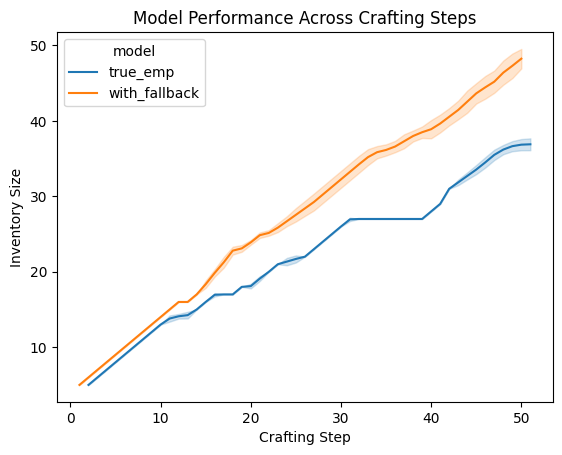

In [18]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
import seaborn as sns
import matplotlib.pyplot as plt

# Example dataframe schema
# df = pd.DataFrame({
#     "model": [...],       # model names (e.g., GPT_FLARE, True_Empowerment, etc.)
#     "trial": [...],       # trial number
#     "step": [...],        # crafting step (1–50)
#     "inventory_size": [...]  # measured model performance
# })

# df = pd.read_csv("combined_inventory_data\combined_inventory_data_true_emp_50iters_20trials.csv")
# Convert `inventory_size` explicitly to numeric, coercing errors to NaN
df["inventory_size"] = pd.to_numeric(df["inventory_size"], errors="coerce")

# Confirm that the structure matches the expected schema
expected_columns = ["model", "trial", "step", "inventory_size"]
assert all(col in df.columns for col in expected_columns), "Column mismatch — please check your file format."

# 1. DESCRIPTIVE STATISTICS ---------------------------------------------------
summary = df.groupby("model")["inventory_size"].agg(["mean", "std", "count"])
print("Descriptive Statistics:\n", summary, "\n")

# 2. PAIRWISE INDEPENDENT T-TESTS --------------------------------------------
models = df["model"].unique()
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        g1 = df[df["model"] == models[i]]["inventory_size"]
        g2 = df[df["model"] == models[j]]["inventory_size"]
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
        print(f"T-Test: {models[i]} vs {models[j]} -> t={t_stat:.4f}, p={p_val:.4f}")

# 3. WILCOXON SIGNED-RANK TEST ------------------------------------------------
# Suitable for paired comparison (same trials or steps)
# Example comparing model pairs trial-by-trial
model_a = "true_emp"
model_b = "with_fallback"

paired_df = df.pivot_table(index="trial", columns="model", values="inventory_size")
paired_df = paired_df.dropna(subset=[model_a, model_b])  # ensure matching pairs

stat, p_val = stats.wilcoxon(paired_df[model_a], paired_df[model_b])
print(f"Wilcoxon signed-rank test ({model_a} vs {model_b}): statistic={stat:.4f}, p={p_val:.4f}")

# 4. REPEATED MEASURES ANOVA --------------------------------------------------
# Aggregate mean performance per trial per model
df_anova = df.groupby(["trial", "model"], as_index=False)["inventory_size"].mean()

# Check shape
print(df_anova.head())

# Perform repeated-measures ANOVA — one within factor ("model")
anova = AnovaRM(df_anova, depvar='inventory_size', subject='trial', within=['model'])
anova_results = anova.fit()
print("\nRepeated Measures ANOVA Results (per-trial means):\n", anova_results)


# anova = AnovaRM(df, depvar='inventory_size', subject='trial', within=['step', 'model'])
# anova_results = anova.fit()
# print("\nRepeated Measures ANOVA Results:\n", anova_results)


# 5. EFFECT SIZE CALCULATIONS -------------------------------------------------
def cohen_d(group1, group2):
    diff = abs(group1.mean() - group2.mean())
    pooled_std = np.sqrt((group1.var() + group2.var()) / 2)
    return diff / pooled_std

print("\nEffect Sizes (Cohen's d):")
for i in range(len(models)):
    for j in range(i + 1, len(models)):
        g1 = df[df["model"] == models[i]]["inventory_size"]
        g2 = df[df["model"] == models[j]]["inventory_size"]
        print(f"{models[i]} vs {models[j]} -> d={cohen_d(g1, g2):.3f}")

# 6. TREND ANALYSIS (REGRESSION SLOPE) ---------------------------------------
print("\nTrend Analysis (Performance Slope Across Steps):")
for model in models:
    mdl_df = df[df["model"] == model]
    X = sm.add_constant(mdl_df["step"])
    y = mdl_df["inventory_size"]
    lm = sm.OLS(y, X).fit()
    slope, p = lm.params["step"], lm.pvalues["step"]
    print(f"{model}: slope={slope:.4f}, p={p:.5f}")

# 7. BOOTSTRAP CONFIDENCE INTERVALS ------------------------------------------
print("\nBootstrap Mean Confidence Intervals (95%):")
for model in models:
    sample = df[df["model"] == model]["inventory_size"].values
    boot_means = [np.mean(np.random.choice(sample, len(sample), replace=True)) for _ in range(2000)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
    print(f"{model}: mean={np.mean(sample):.3f}, 95% CI=({ci_low:.3f}, {ci_high:.3f})")

# 8. VISUALIZATION ------------------------------------------------------------
sns.lineplot(data=df, x="step", y="inventory_size", hue="model", ci="sd")
plt.title("Model Performance Across Crafting Steps")
plt.xlabel("Crafting Step")
plt.ylabel("Inventory Size")
plt.show()


In [12]:
print("Unique model names:")
print(df["model"].unique())

Unique model names:
['inventory_run_1' 'inventory_run_10' 'inventory_run_11'
 'inventory_run_12' 'inventory_run_13' 'inventory_run_14'
 'inventory_run_15' 'inventory_run_16' 'inventory_run_17'
 'inventory_run_18' 'inventory_run_19' 'inventory_run_2'
 'inventory_run_20' 'inventory_run_3' 'inventory_run_4' 'inventory_run_5'
 'inventory_run_6' 'inventory_run_7' 'inventory_run_8' 'inventory_run_9']
